In [ ]:
# !nvidia-smi

In [ ]:
# import torch
# print("Torch version:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))
# else:
#     print("No GPU detected")

In [ ]:
import zipfile

zip_path = "../einstein_rings/einstein_rings_128.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    image_files = [f for f in z.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Total images:", len(image_files))

Total images: 195


In [ ]:
import os
from pathlib import Path

# ZIP_PATH =  "../einstein_rings/einstein_rings_128.zip"
DATA_DIR = "../einstein_rings/einstein_rings_all"
OUTPUT_DIR =  "../einstein_rings/diffusion_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: ../einstein_rings/einstein_rings_all
OUTPUT_DIR: ../einstein_rings/diffusion_output


In [ ]:
# %%capture
# !pip install -U diffusers[training]

In [ ]:
# %%capture
# !sudo apt -qq install git-lfs
# !git config --global credential.helper store

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 64 
    train_batch_size = 4
    eval_batch_size = 4 
    num_epochs = 300
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 100 
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16'
    output_dir = 'ema-es-64-(3)'
    push_to_hub = False # Set to False if you haven't fixed the 401 error yet
    overwrite_output_dir = True
    seed = 0

config = TrainingConfig()

In [ ]:
from pathlib import Path
import os

valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

best_folder = None
best_count = 0

for root, dirs, files in os.walk(DATA_DIR):
    count = sum(1 for f in files if Path(f).suffix.lower() in valid_exts)
    if count > best_count:
        best_count = count
        best_folder = root

print("Best image folder:", best_folder)
print("Number of images:", best_count)

Best image folder: ../einstein_rings/einstein_rings_all
Number of images: 195


Found images: 195


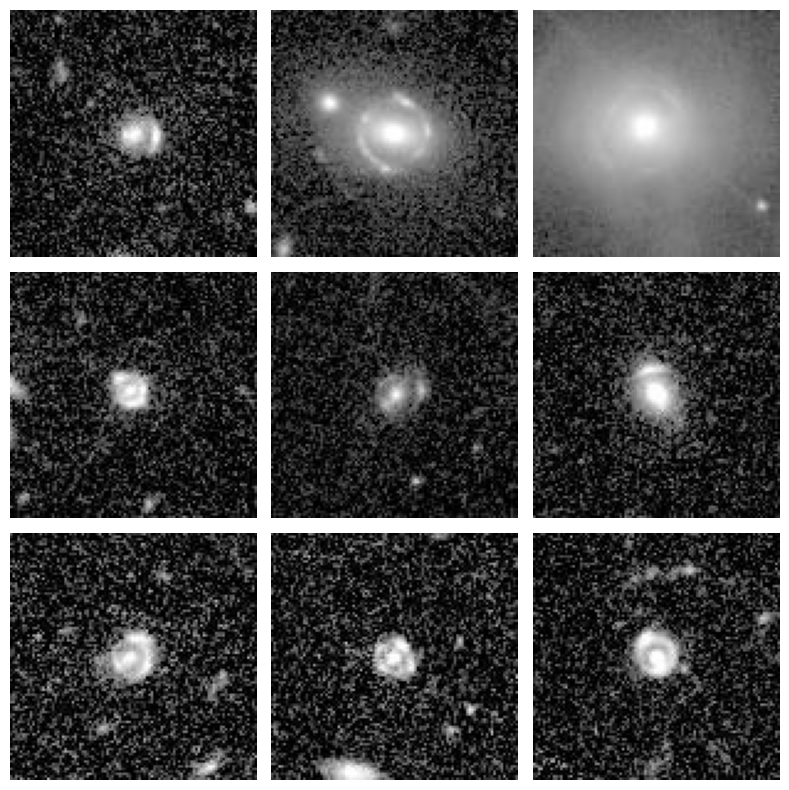

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

image_paths = []
for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in valid_exts:
        image_paths.append(str(p))

print("Found images:", len(image_paths))

sample_paths = random.sample(image_paths, min(9, len(image_paths)))

plt.figure(figsize=(8, 8))
for i, path in enumerate(sample_paths, 1):
    img = Image.open(path).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

# preprocess = transforms.Compose(
#     [
#         transforms.Resize((config.image_size, config.image_size)),
#         transforms.RandomHorizontalFlip(),
#         transforms.ToTensor(),
#         transforms.Normalize([0.5], [0.5]),
#     ]
# )
def log_transform(x):
    # This brings out the faint arcs without blowing out the center
    return torch.log1p(x * 100) / torch.log1p(torch.tensor(100.0))

preprocess = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.Grayscale(num_output_channels=1), # Add this line
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180, fill=0),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

In [ ]:
import torch
train_dataloader = torch.utils.data.DataLoader(DATA_DIR, batch_size=config.train_batch_size, shuffle=True)

In [ ]:
from diffusers import UNet2DModel

from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=config.image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    # 4 stages are perfect for 64x64 resolution
    block_out_channels=(64, 128, 256, 512), 
    down_block_types=(
        "DownBlock2D",      # 64 -> 32
        "DownBlock2D",      # 32 -> 16
        "AttnDownBlock2D",  # 16 -> 8 (Attention is best at low res)
        "DownBlock2D",      # 8 -> 4
    ),
    up_block_types=(
        "UpBlock2D",        # 4 -> 8
        "AttnUpBlock2D",    # 8 -> 16
        "UpBlock2D",        # 16 -> 32
        "UpBlock2D",        # 32 -> 64
    ),
)
# Enable checkpointing to save even more memory
model.enable_gradient_checkpointing()

In [ ]:
from PIL import Image
from pathlib import Path
from collections import Counter

sizes = []

for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".webp"]:
        img = Image.open(p)
        sizes.append(img.size)

# Count occurrences of each size
size_count = Counter(sizes)

print("Image size distribution:")
for size, count in size_count.items():
    print(f"{size}: {count} images")

if sample_paths:
  example_image_path = sample_paths[0]
  example_image = Image.open(example_image_path).convert("RGB")
  preprocessed_image = preprocess(example_image)
  print('Input shape after preprocessing:', preprocessed_image.shape)

else:
  print("No sample paths found to determine image shape.")

Image size distribution:
(100, 100): 195 images
Input shape after preprocessing: torch.Size([1, 64, 64])


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path

# transform = transforms.Compose([
#     transforms.Resize((128,128)),
#     transforms.ToTensor(),            # [0,1]
#     transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
# ])

images = []

for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in valid_exts:
        img = Image.open(p).convert("RGB")
        img = preprocess(img)
        images.append(img)

images = torch.stack(images)  # shape: [N, 3, 64, 64]

print("Tensor shape:", images.shape)

Tensor shape: torch.Size([195, 1, 64, 64])


In [ ]:
# from diffusers import DDPMScheduler

# noise_scheduler = DDPMScheduler(num_train_timesteps=200)

In [ ]:
from diffusers import DDPMScheduler

# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2", # Change from "linear" to this
    clip_sample=True # This forces the model to stay within bounds
)

noise = torch.randn_like(images)

timesteps = torch.randint(0, 100, (images.shape[0],))

noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

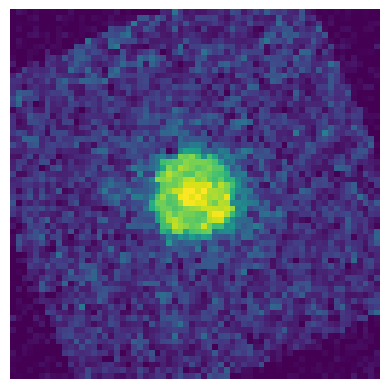

In [ ]:
import matplotlib.pyplot as plt

img = noisy_images[190]

# convert back to [0,1]
img = (img.clamp(-1, 1) + 1) / 2
img = img.permute(1, 2, 0).cpu().numpy()



plt.imshow(img)
plt.axis("off")
plt.show()

Your original astronomy images are probably close to grayscale, but you converted them to RGB. Then Gaussian noise is added independently to each channel, so the result becomes colorful static. That is normal.


Show the same image at multiple timesteps:

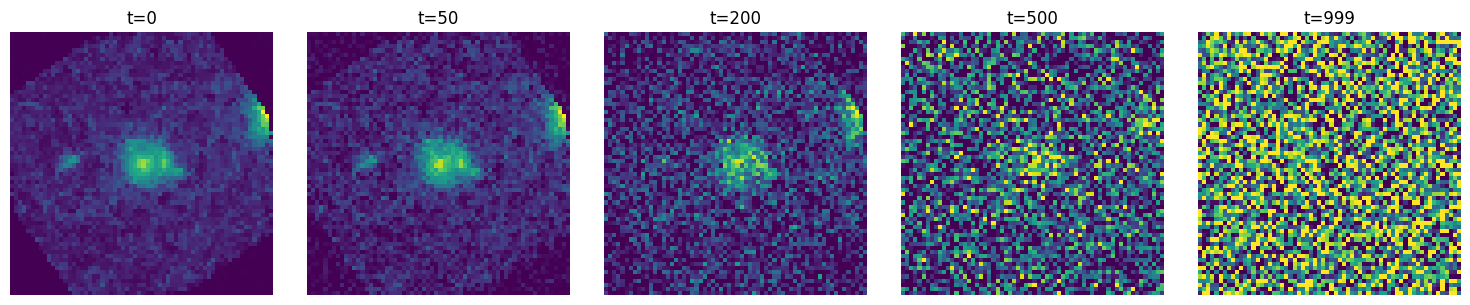

In [ ]:
import matplotlib.pyplot as plt
import torch

img = images[3:4]  # one image, keep batch dim

steps = [0, 50, 200, 500, 999]

plt.figure(figsize=(15, 3))
for i, step in enumerate(steps, 1):
    noise = torch.randn_like(img)
    t = torch.tensor([step])
    noisy = noise_scheduler.add_noise(img, noise, t)

    show = (noisy[0].clamp(-1, 1) + 1) / 2
    show = show.permute(1, 2, 0).cpu().numpy()

    plt.subplot(1, len(steps), i)
    plt.imshow(show)
    plt.title(f"t={step}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Ensure 'images' is a single big tensor (you already did this with torch.stack)
# images.shape should be [195, 3, 64, 64]

# 2. Wrap it in a Dataset so the DataLoader knows what to do with it
dataset = TensorDataset(images)

# 3. Create the DataLoader
train_dataloader = DataLoader(
    dataset,
    batch_size=config.train_batch_size,
    shuffle=True
)

In [ ]:
# from huggingface_hub import notebook_login

# notebook_login()

from huggingface_hub import login
login(token="HF_TOKEN")

In [ ]:
import torch.nn.functional as F
# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.enable_gradient_checkpointing()
# 2. Ensure model is on that device (do this once during setup)
model.to(device)

# 3. Move tensors to the device inside training loop
noisy_images = noisy_images.to(device)
timesteps = timesteps.to(device)
noise = noise.to(device) 

def tv_loss(img):
    # This measures the "jitter" between pixels
    w_variance = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    h_variance = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return h_variance + w_variance

# Inside training loop:
noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
mse = F.mse_loss(noise_pred, noise)
# 0.00001 is a good starting point to clean the background without blurring the ring
loss = mse + 0.00001 * tv_loss(noise_pred)

C:\Users\teunm\AppData\Local\Temp\ipykernel_48120\3578620517.py:22: UserWarning: Using a target size (torch.Size([1, 1, 64, 64])) that is different to the input size (torch.Size([195, 1, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = F.mse_loss(noise_pred, noise)


In [ ]:
# import torch.nn.functional as F

# noise_pred = model(noisy_images, timesteps).sample
# loss = F.mse_loss(noise_pred, noise)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

In [ ]:
from diffusers import DDPMPipeline

import math

def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size = config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
    ).images

    # Make a grid out of the images
    image_grid = make_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from huggingface_hub import create_repo, upload_folder
from diffusers.training_utils import EMAModel # Import EMA
from diffusers import DDPMPipeline
import torch.nn.functional as F
import torch
from tqdm.auto import tqdm
from pathlib import Path
import os

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    logging_dir = os.path.join(config.output_dir, "logs")
    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)
    
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )

    if accelerator.is_main_process:
        if config.push_to_hub:
            repo_id = create_repo(repo_id=Path(config.output_dir).name, exist_ok=True).repo_id
        elif config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    # --- 1. Initialize EMA Model ---
    # We create a copy of the model parameters to maintain the moving average
    ema_model = EMAModel(model.parameters(), decay=0.999)

    # Prepare everything
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            # Standard data prep
            clean_images = batch[0]
            noise = torch.randn_like(clean_images)
            bs = clean_images.shape[0]
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()
                
                # --- 2. Update EMA weights ---
                # This should happen after the optimizer step
                ema_model.step(model.parameters())

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # --- 3. Evaluate and Save using EMA Weights ---
        if accelerator.is_main_process:
            # We want to evaluate the "smoothed" version of the model
            # First, temporarily copy EMA weights into the model
            ema_model.copy_to(model.parameters())
            
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch} (EMA)",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)
            
            # NOTE: After saving/evaluating with EMA weights, your training continues 
            # using the weights that were already in 'model'. The copy_to() only 
            # affected the current epoch's evaluation/save.

In [ ]:
# from accelerate import Accelerator
# from accelerate.utils import ProjectConfiguration
# from huggingface_hub import create_repo, upload_folder

# from tqdm.auto import tqdm
# from pathlib import Path
# import os

# def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
#     # Initialize accelerator and tensorboard logging
#     logging_dir = os.path.join(config.output_dir, "logs")
#     accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)
#     accelerator = Accelerator(
#         mixed_precision=config.mixed_precision,
#         gradient_accumulation_steps=config.gradient_accumulation_steps,
#         log_with="tensorboard",
#         project_config=accelerator_project_config,
#     )
#     if accelerator.is_main_process:
#         if config.push_to_hub:
#             repo_id = create_repo(
#                 repo_id=Path(config.output_dir).name, exist_ok=True
#             ).repo_id
#         elif config.output_dir is not None:
#             os.makedirs(config.output_dir, exist_ok=True)
#         accelerator.init_trackers("train_example")

#     # Prepare everything
#     # There is no specific order to remember, you just need to unpack the
#     # objects in the same order you gave them to the prepare method.
#     model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
#         model, optimizer, train_dataloader, lr_scheduler
#     )

#     global_step = 0

#     # Now you train the model
#     for epoch in range(config.num_epochs):
#         progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
#         progress_bar.set_description(f"Epoch {epoch}")

#         for step, batch in enumerate(train_dataloader):
#             # clean_images = batch
#             # # Sample noise to add to the images
#             # noise = torch.randn(clean_images.shape).to(clean_images.device)
#             # bs = clean_images.shape[0]

#             clean_images = batch[0]

#             # Move to GPU
#             clean_images = clean_images.to(accelerator.device)

#             # Sample noise
#             noise = torch.randn_like(clean_images)
#             bs = clean_images.shape[0]

#             # Sample a random timestep for each image
#             timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

#             # Add noise to the clean images according to the noise magnitude at each timestep
#             # (this is the forward diffusion process)
#             noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

#             with accelerator.accumulate(model):
#                 # Predict the noise residual
#                 noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
#                 loss = F.mse_loss(noise_pred, noise)
#                 accelerator.backward(loss)

#                 accelerator.clip_grad_norm_(model.parameters(), 1.0)
#                 optimizer.step()
#                 lr_scheduler.step()
#                 optimizer.zero_grad()

#             progress_bar.update(1)
#             logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
#             progress_bar.set_postfix(**logs)
#             accelerator.log(logs, step=global_step)
#             global_step += 1

#         # After each epoch you optionally sample some demo images with evaluate() and save the model
#         if accelerator.is_main_process:
#             pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

#             if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
#                 evaluate(config, epoch, pipeline)

#             if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
#                 if config.push_to_hub:
#                     upload_folder(
#                         repo_id=repo_id,
#                         folder_path=config.output_dir,
#                         commit_message=f"Epoch {epoch}",
#                         ignore_patterns=["step_*", "epoch_*"],
#                     )
#                 else:
#                     pipeline.save_pretrained(config.output_dir)

In [ ]:
from accelerate import notebook_launcher
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


Epoch 0: 100%|██████████| 49/49 [00:10<00:00,  5.31it/s, loss=0.43, lr=4.9e-5, step=48]  

Epoch 0: 100%|██████████| 49/49 [00:10<00:00,  4.76it/s, loss=0.43, lr=4.9e-5, step=48]






































































































































































































Epoch 9: 100%|██████████| 49/49 [06:39<00:00,  8.15s/it, loss=0.0353, lr=9.98e-5, step=489]


KeyboardInterrupt: 

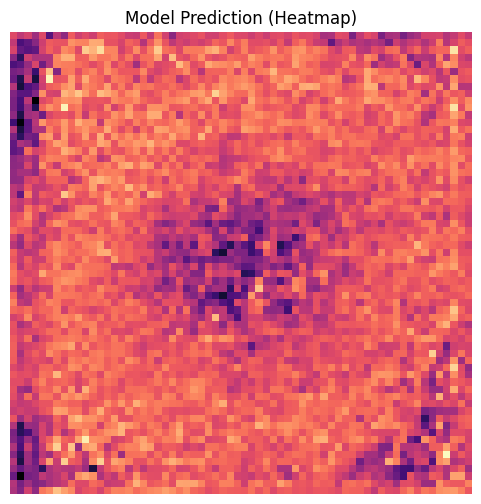

In [ ]:
import matplotlib.pyplot as plt

# Grab a sample from the model output
sample = noise_pred[0].detach().cpu()
# Reverse normalization correctly (ONLY ONCE)
sample = (sample / 2 + 0.5).clamp(0, 1)

# If it's 3-channel, convert to grayscale to see the ring structure better
if sample.shape[0] == 3:
    sample = sample.mean(dim=0)

plt.figure(figsize=(6,6))
# 'magma' or 'inferno' are much better for seeing faint astronomical rings
plt.imshow(sample, cmap='magma')
plt.title("Model Prediction (Heatmap)")
plt.axis("off")
plt.show()

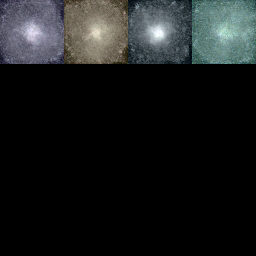

In [ ]:
import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])